# Homework: The Perceptron

$
\newcommand{\xv}{\mathbf{x}}
\newcommand{\wv}{\mathbf{w}}
\newcommand{\yv}{\mathbf{y}}
\newcommand{\tv}{\mathbf{t}}
\newcommand{\zv}{\mathbf{z}}
\newcommand{\uv}{\mathbf{u}}
\newcommand{\vv}{\mathbf{v}}
\newcommand{\bv}{\mathbf{b}}
\newcommand{\av}{\mathbf{a}}
\newcommand{\hv}{\mathbf{h}}
\newcommand{\onev}{\mathbf{1}}
\newcommand{\zerov}{\mathbf{0}}
\newcommand{\Chi}{\mathcal{X}}
\newcommand{\R}{\rm I\!R}
\newcommand{\sign}{\text{sign}}
\newcommand{\Ym}{\mathbf{Y}}
\newcommand{\Tm}{\mathbf{T}}
\newcommand{\Xm}{\mathbf{X}}
\newcommand{\Wm}{\mathbf{W}}
\newcommand{\Zm}{\mathbf{Z}}
\newcommand{\Um}{\mathbf{U}}
\newcommand{\Vm}{\mathbf{V}}
\newcommand{\Am}{\mathbf{A}}
\newcommand{\Hm}{\mathbf{H}}
\newcommand{\Idm}{\mathbf{I}}
\newcommand{\muv}{\boldsymbol\mu}
\newcommand{\Sigmav}{\boldsymbol\Sigma}
\newcommand{\Lambdav}{\boldsymbol\Lambda}
\newcommand{\xspace}{\mathcal{X}}
\newcommand{\yspace}{\mathcal{Y}}
\newcommand{\ind}{\perp\!\!\!\!\!\perp}
$

## Name: <span style="color:blue"> *Shashank PB* </span>

## Utils

In [2]:
from typing import List, Dict, Tuple, Callable
import os
import gc
import traceback
import warnings
from pdb import set_trace

import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
class TodoCheckFailed(Exception):
    pass

def todo_check(asserts, mute=False, success_msg="", **kwargs):
    locals().update(kwargs)
    failed_err = "You passed {}/{} and FAILED the following code checks:\n{}"
    failed = ""
    n_failed = 0
    for check, (condi, err) in enumerate(asserts):
        exc_failed = False
        if isinstance(condi, str):
            try:
                passed = eval(condi)
            except Exception:
                exc_failed = True
                n_failed += 1
                failed += f"\nCheck [{check+1}]: Failed to execute check [{check+1}] due to the following error...\n{traceback.format_exc()}"
        elif isinstance(condi, bool):
            passed = condi
        else:
            raise ValueError("asserts must be a list of strings or bools")

        if not exc_failed and not passed:
            n_failed += 1
            failed += f"\nCheck [{check+1}]: Failed\n\tTip: {err}\n"

    if len(failed) != 0:
        passed = len(asserts) - n_failed
        err = failed_err.format(passed, len(asserts), failed)
        raise TodoCheckFailed(err.format(failed))
    if not mute: print(f"Your code PASSED all the code checks! {success_msg}")

## Instructions
In this assignment, you will be implementing Rosenblatt's perceptron. To do so, you will be working with the Iris dataset and will practice binarizing the classes to be either a one-vs-all or one-vs-one classification problem. Additionally, you will practice implementing various classification metrics.

Your job is to read through the assignment and fill in any code segments that are marked by `TODO` headers and comments. Some TODOs will have a `todo_check()` function which will give you a rough estimate of whether your code is functioning as excepted. Other's might not have these checks, like visualization TODOs. Regardless,  all the correct outputs are given below each code cell. It might be useful to copy the contents of certain TODO cells into a new cell so you can try to match the desired output with the output produced by your own code! For visualization TODOs, you simply have to have a plot that looks similar. You can change aspects such as color, titles, or x/y-axis labels if you so wish.

At any point, if you feel lost concerning how to program a specific TODO, take some time and visit the official documentation for each library and read about the methods/functions that you need to use.

## Submission

1. Save the notebook.
2. Enter your name in the appropriate markdown cell provided at the top of the notebook.
3. Select `Kernel` -> `Restart Kernel and Run All Cells`. This will restart the kernel and run all cells. Make sure everything runs without errors and double-check the outputs are as you desire!
4. Submit the `.ipynb` notebook on Canvas.


# Perceptron

## Wine Dataset
<center><img src="https://storage.googleapis.com/kaggle-datasets-images/4216619/7273508/a81ae586f1c99060f361020fbf15fd6c/dataset-cover.jpg?t=2023-12-24-17-14-07"></center>


This assignment will have you tackle the famous Wine classification problem, where the goal is to classify wine developed by three different cultivars. The Wine dataset is a frequently used dataset when first being introduced to classification in machine learning. Below is a description of the dataset taken from [GeeksForGeeks](https://www.geeksforgeeks.org/wine-dataset/) and [UCI](https://archive.ics.uci.edu/dataset/109/wine).

> The wine dataset contains the results of a chemical analysis of wines grown in three different regions in Italy. Specifically, it includes 13 attributes derived from measurements of various constituents found in the wines. These attributes typically include factors like alcohol content, acidity levels, and concentrations of different chemical compounds such as phenols and flavonoids. These attributes provide valuable insights into the chemical composition of wines and can be utilized for wine classification tasks.

Finally, recall that the labels are as follows: **label 0 corresponds to class_0, label 1 corresponds to class_1, and label 2 corresponds to class_2**, as the class labels in `wine.target` correspond to the index of `wine.target_names`.

Thus, the goal of this dataset is a **3-way multi-classification problem**, where you must classify each data sample into one of the three wine classes. **However, this conflicts with the perceptron, which can only perform binary classification. To overcome this, you will need to select only two classes or implement a one-vs-all (OvA) classification strategy!**

## Data Loading

#### TODO 1 (5 points): Data Loading
Complete the TODO by loading the Wine dataset using Sklearn.

1. Load the Wine dataset by calling Sklearn's `load_wine()` function and pass the parameter that returns the data as a pandas DataFrame. Store the output into `wine`.

In [4]:
# TODO 1.1
from sklearn.datasets import load_wine
from sklearn.utils import Bunch

wine = Bunch = load_wine(as_frame=True)

In [5]:
todo_check([
    ("isinstance(wine, sklearn.utils.Bunch)", "'wine' is not of type Bunch"),
    ("isinstance(wine.data, pd.DataFrame)", "wine.data is not a Pandas DataFrame. Make sure to pass the correct argument to load_wine()."),
    ("isinstance(wine.target, pd.Series)", "wine.target is not a Pandas series. Make sure to pass the correct argument to load_wine()."),
])

Your code PASSED all the code checks! 


In [6]:
wine.data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [7]:
wine.target

,target
0,0
1,0
2,0
3,0
4,0
...,...
173,2
174,2
175,2
176,2


## Visualization

Recall, the below is the scatter matrix or pairplot for the Iris data. Take note of which classes look to be linearly separable and which do not!

If you are having a hard time seeing the graph, double-click the plot to zoom in. Additionally, feel free to adjust the `height` argument to make the plot more readable or comment out the code if it is taking awhile to run.

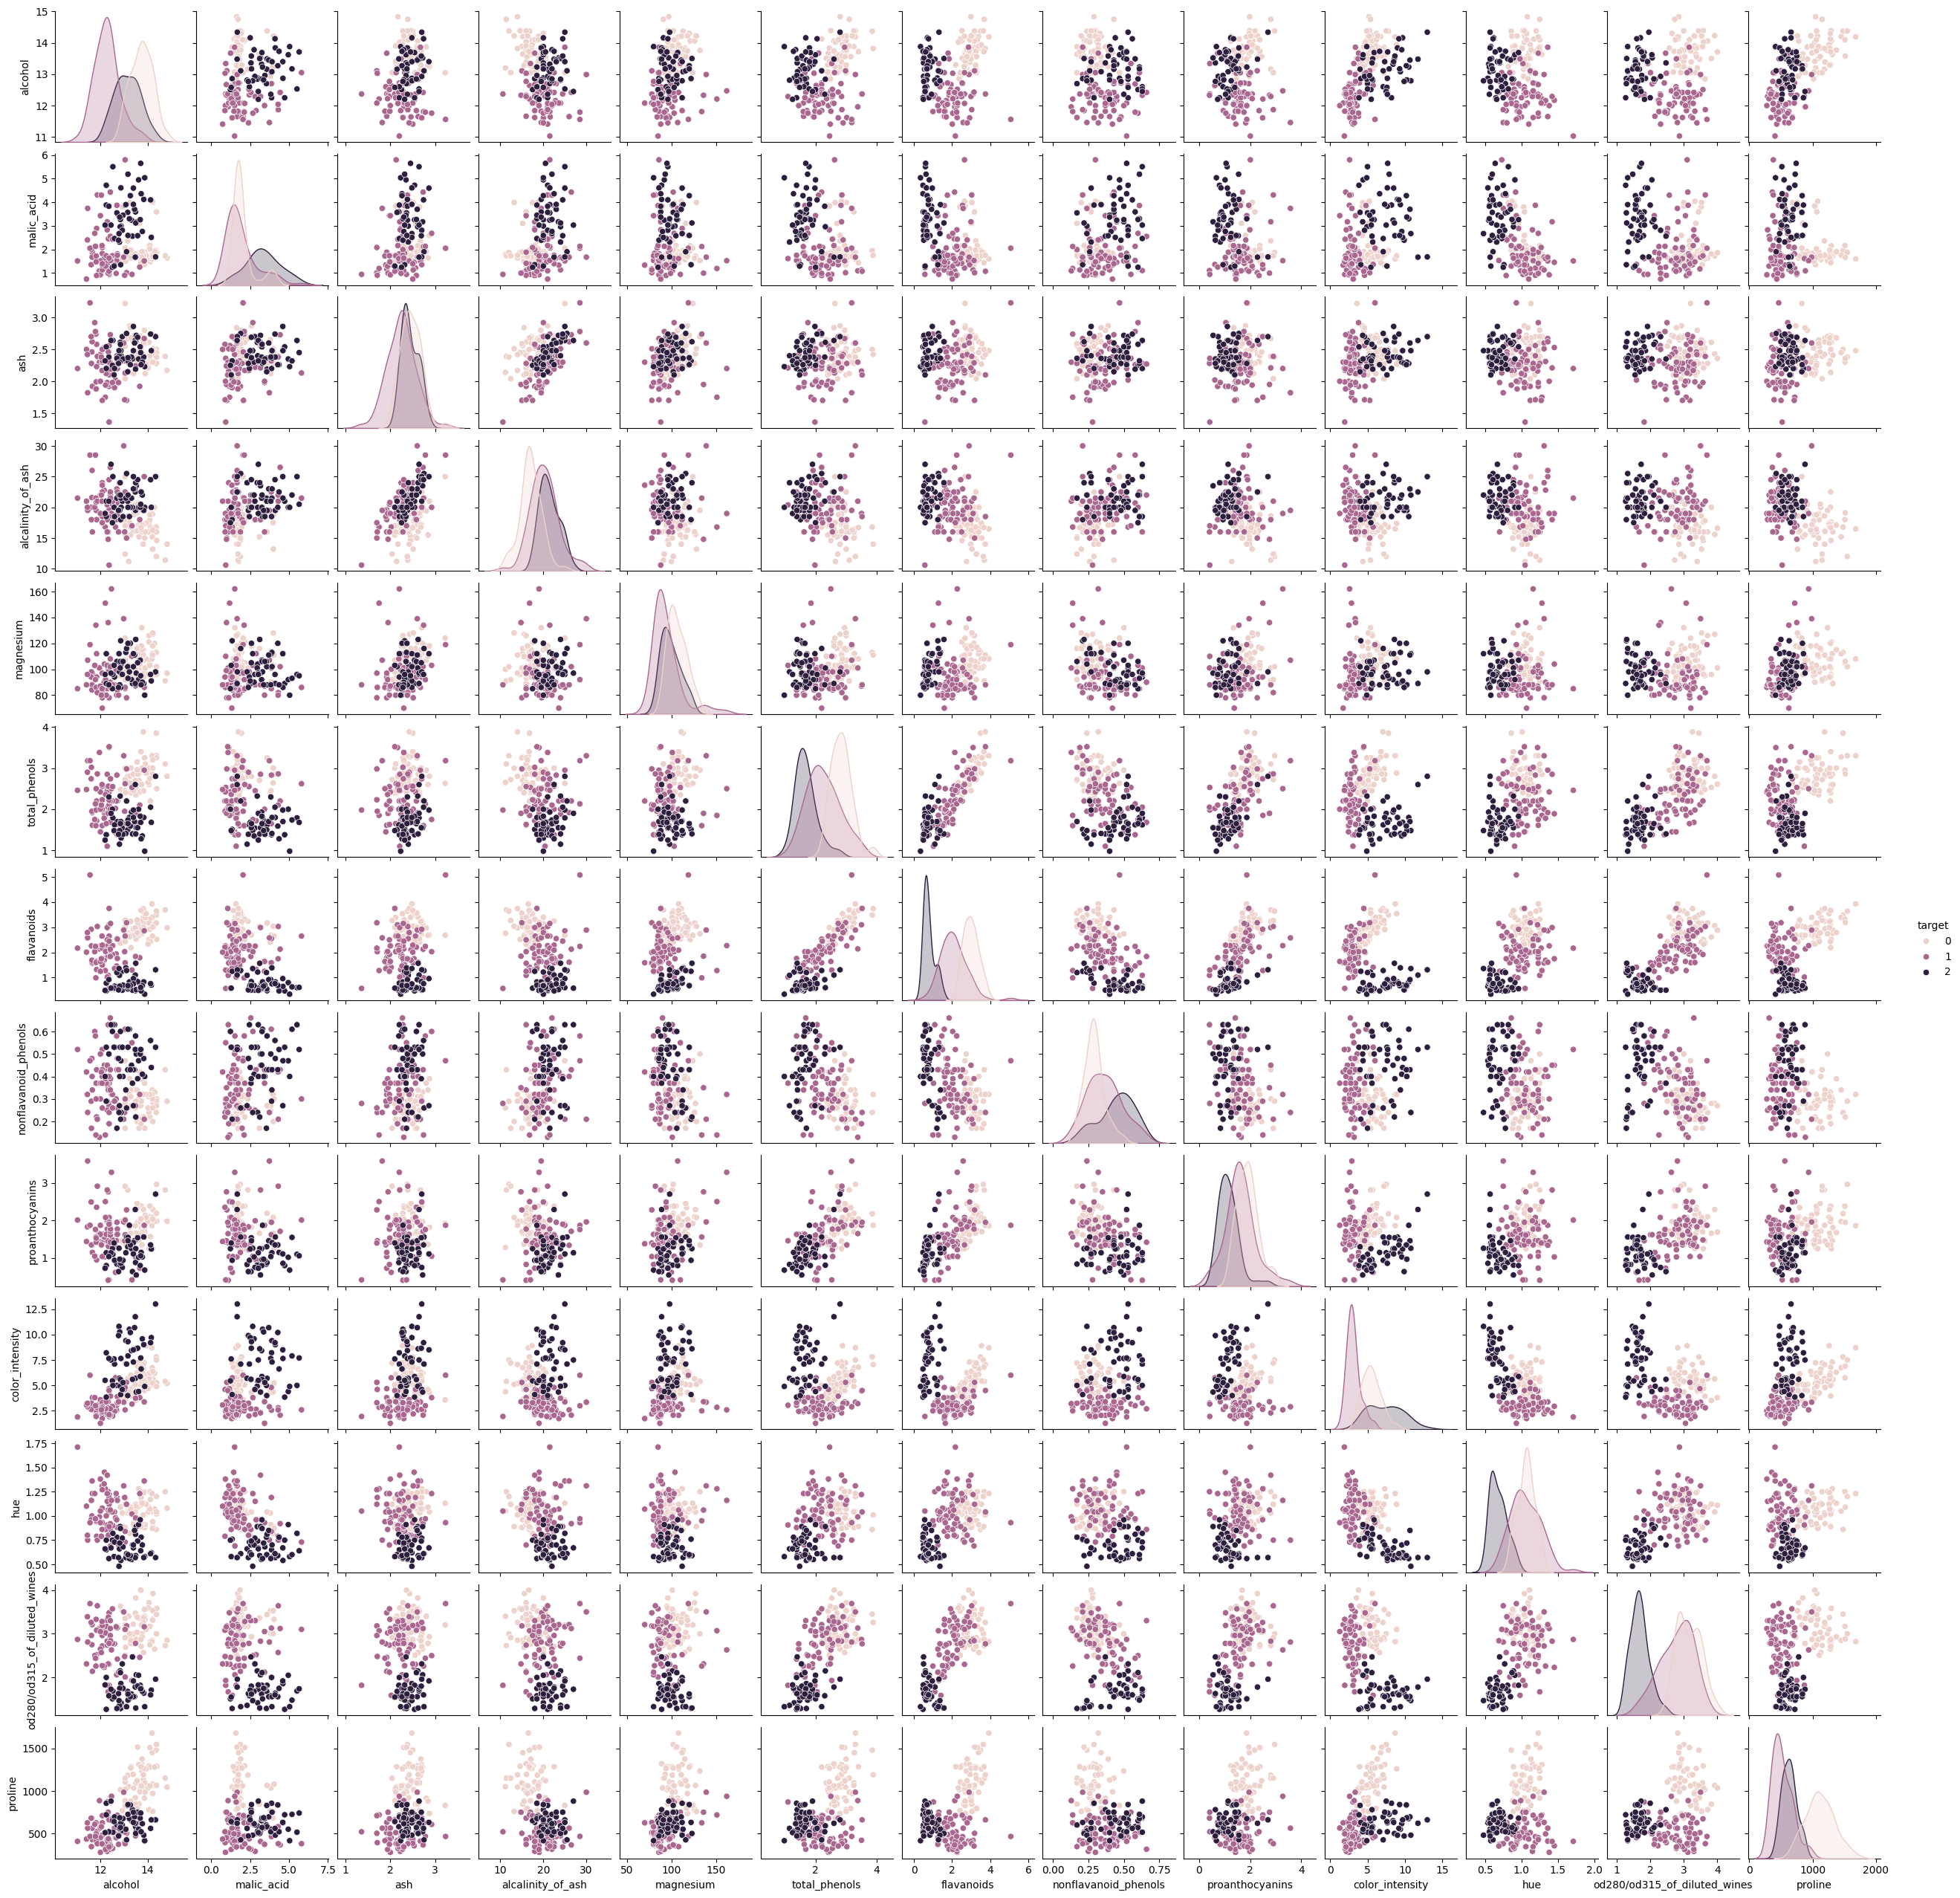

In [8]:
from seaborn import pairplot
pairplot(pd.concat([wine.data, wine.target], axis=1), hue='target', height=2);

## Data Preprocessing

### Binarize Classes
As the wine dataset is a multiclass classification problem, we need to binarize the classes so that we can have a binary classification problem for the perceptron to work.

#### TODO 2 (10 Points): Binarize Labels
Complete the `binarize_classes()` function, which converts the Wine dataset into either a one-vs-one or one-vs-all classification problem.

1. Use the `pos_class` list to find all positive class data `X` and labels `y`. Set the positive class labels to 1. Store the positive class data samples into `X_pos` and labels into `y_pos`.
<br><br>
2. Use the `neg_class` list to find all negative class data `X` and labels `y`. Set the negative class labels to -1. Store the negative class data samples into `X_neg` and labels into `y_neg`.

**Hints:**
- Refer to the notes on binarizing classes. Unlike the notes, you will also need to index the corresponding `X` data for the positive and negative labels.


In [9]:
def binarize_classes(
    X: np.ndarray,
    y: np.ndarray,
    pos_class: List[int],
    neg_class: List[int]
) -> Tuple[np.ndarray, np.ndarray]:
    """ Converts data into a one-vs-all or one-vs-one prolbem
        according to labels passed as pos or neg.

        Args:
            X: Input data given as matrix

            y: Labels corresponding to input data given as 1D vector

            pos_class: list of labels that will be used for
                the positive class.

            neg_class: list of labels that will be used for
                the negative class.

        Returns:
            Two arrays where the 1st corresponds to the data
            given as a matrix and the 2nd corresponds to the
            new labels given as a 1D vector.
    """
    assert isinstance(X, np.ndarray), f"X is not an NumPy array, got type {type(X)}."
    assert isinstance(y, np.ndarray), f"y is not an NumPy array, got type {type(y)}."
    X = X.copy()
    y = y.copy()

    # TODO 2.1
    pos_indices = np.isin(y, pos_class)
    X_pos = X[pos_indices]
    y_pos = np.ones(X_pos.shape[0], dtype=np.int8)


    # TODO 2.2
    neg_indices = np.isin(y, neg_class)
    X_neg = X[neg_indices]
    y_neg = np.ones(X_neg.shape[0], dtype=np.int8) * -1


    return np.vstack([X_pos, X_neg]), np.hstack([y_pos, y_neg])

In [10]:
def TEST_binarize_classes():
    print("-"*50)
    one_vs_one = binarize_classes(
        X=wine.data.values,
        y=wine.target.values,
        pos_class=[0],
        neg_class=[1]
    )
    print(f"one_vs_one X shape: {one_vs_one[0].shape}")
    print(f"one_vs_one y shape: {one_vs_one[1].shape}")
    print("-"*50)

    one_vs_all = binarize_classes(
        X=wine.data.values,
        y=wine.target.values,
        pos_class=[1],
        neg_class=[0, 2]
    )
    print(f"one_vs_all X shape: {one_vs_all[0].shape}")
    print(f"one_vs_all y shape: {one_vs_all[1].shape}")
    print("-"*50)

    todo_check([
        # one vs one
        ("one_vs_one[1].shape == (130,)", "Wrong shape for one_vs_one labels, expected shape (130,)"),
        ("one_vs_one[0].shape == (130,13)", "Wrong shape for one_vs_one data X, expected shape (130, 13)"),
        ("np.all(np.unique(one_vs_one[1]) == np.array([-1, 1]))", f"Wrong class labels found for one_vs_one, got {np.unique(one_vs_one[1])} instead of [-1, 1]"),
        ("np.all(one_vs_one[0][4] == np.array([13.24, 2.59, 2.87, 21.0, 118.0, 2.8, 2.69, 0.39, 1.82, 4.32, 1.04, 2.93, 735.0]))", "Potentially wrong positive data values found for one_vs_one."),
        ("np.all(one_vs_one[0][95] == np.array([12.47, 1.52, 2.2, 19.0, 162.0, 2.5, 2.27, 0.32, 3.28, 2.6, 1.16, 2.63, 937.0]))", "Potentially wrong negative data values found for one_vs_one."),
        # one vs all
        ("one_vs_all[1].shape == (178,)", "Wrong shape for one_vs_all labels, expected shape (178,)"),
        ("one_vs_all[0].shape == (178,13)", "Wrong shape for one_vs_all data X, expected shape (178, 13)"),
        ("np.all(np.unique(one_vs_all[1]) == np.array([-1, 1]))", f"Wrong class labels found for one_vs_all, got {np.unique(one_vs_all[1])} instead of [-1, 1]"),
        ("np.all(one_vs_all[0][4] == np.array([12.37, 1.13, 2.16, 19.0, 87.0, 3.5, 3.1, 0.19, 1.87, 4.45, 1.22, 2.87, 420.0]))", "Potentially wrong positive data values found for one_vs_all."),
        ("np.all(one_vs_all[0][125] == np.array([13.74, 1.67, 2.25, 16.4, 118.0, 2.6, 2.9, 0.21, 1.62, 5.85, 0.92, 3.2, 1060.0]))", "Potentially wrong negative data values found for one_vs_all."),
    ], **locals())

TEST_binarize_classes()

--------------------------------------------------
one_vs_one X shape: (130, 13)
one_vs_one y shape: (130,)
--------------------------------------------------
one_vs_all X shape: (178, 13)
one_vs_all y shape: (178,)
--------------------------------------------------
Your code PASSED all the code checks! 


### Data Splitting

In [11]:
from sklearn.model_selection import train_test_split
def get_train_valid_test_data(
    X: np.ndarray,
    y: np.ndarray,
):
    """ Randomizes and then splits the data into train, validation, and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector
    """
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=.8, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, train_size=.8, random_state=42)

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

### Putting it all together

Recall, in order to prepare the data, you will need to split the data, standardize, and add the bias. However, now you will need to binarize the classes before doing any of these steps. Thus, it is time to combine all the data preprocessing steps into one function which returns the fully preprocessed data.

#### TODO 3 (10 points): Preprocess Data

Complete the following the `get_preprocessed_data()` function for performing data preprocessing.

1. Call the `binarize_classes()` function to binarize the `wine` data. Store the output into `X` and `y`.
    1. Hint: Do so by passing `pos_class` and `neg_class` as the positive and negative class labels.
    2. Hint: Make sure to pass your data and labels as NumPy arrays.
<br><br>
3. Call the `get_train_valid_test_data()` function to split the data. Store the output into `X_trn`, `y_trn`, `X_vld`, `y_vld`, `X_tst`, and `y_tst`.
<br><br>
4. Use Sklearn's `StandardScaler` class to standardize all the datasets. Do so by computing the mean and STD using the training data, and then transforming the training, validation, and testing data. Store the output back inside `X_trn`, `X_vld`, and `X_tst`.
<br><br>
5. Add the bias to the first column of the training `X_trn`, validation `X_vld`, and testing `X_tst` data. Store the output back into `X_trn`, `X_vld`, and `X_tst`.

In [16]:
from sklearn.preprocessing import StandardScaler
def get_preprocessed_data(pos_class: List[int], neg_class: List[int])  -> Tuple[np.ndarray]:
    """ Gets preprocessed data for training, validation, and testing

        Args:
            pos_class: list of labels that will be used for
                the positive class.

            neg_class: list of labels that will be used for
                the negative class.

        Return:
            A tuple of NumPy arrays where indices 0-1
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """
    # TODO 3.1
    X, y = binarize_classes(wine.data.values, wine.target.values, pos_class, neg_class)

    # TODO 3.2
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y)


    # TODO 3.3
    scaler = StandardScaler()
    X_trn = scaler.fit_transform(X_trn)
    X_vld = scaler.transform(X_vld)
    X_tst = scaler.transform(X_tst)

    # TODO 3.4
    bias_trn = np.ones((X_trn.shape[0], 1))
    X_trn = np.hstack((bias_trn, X_trn))

    bias_vld = np.ones((X_vld.shape[0], 1))
    X_vld = np.hstack((bias_vld, X_vld))

    bias_tst = np.ones((X_tst.shape[0], 1))
    X_tst = np.hstack((bias_tst, X_tst))

    # Reshape targets to be 2D column vectors
    return X_trn, y_trn.reshape(-1, 1), X_vld, y_vld.reshape(-1, 1), X_tst, y_tst.reshape(-1, 1)

In [17]:
def TEST_get_preprocessed_data():
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data(pos_class=[2], neg_class=[0,1])

    print(f"X_trn shape: {X_trn.shape}")
    print(f"y_trn shape: {y_trn.shape}")

    print(f"X_vld shape: {X_vld.shape}")
    print(f"y_vld shape: {y_vld.shape}")

    print(f"X_tst shape: {X_tst.shape}")
    print(f"y_tst shape: {y_tst.shape}")

    print(f"X_trn means:\n{X_trn.mean(axis=0)}")
    print(f"X_vld means:\n{X_vld.mean(axis=0)}")
    print(f"X_tst means:\n{X_tst.mean(axis=0)}")

    todo_check([
        # Split and binarize tests
        ("isinstance(X_trn, np.ndarray)", "X_trn must be a NumPy array."),
        ("isinstance(X_vld, np.ndarray)", "X_vld must be a NumPy array."),
        ("isinstance(X_tst, np.ndarray)", "X_tst must be a NumPy array."),
        ("isinstance(y_trn, np.ndarray)", "y_trn must be a NumPy array."),
        ("isinstance(y_vld, np.ndarray)", "y_vld must be a NumPy array."),
        ("isinstance(y_tst, np.ndarray)", "y_tst must be a NumPy array."),
        ("len(y_trn) == 113", "Training data has incorrect number of data samples."),
        ("len(y_vld) == 29", "Validation data has incorrect number of data samples."),
        ("len(y_tst) == 36", "Testing data has incorrect number of data samples."),
        ("abs(y_trn[y_trn == -1].sum()) == 84", "y_trn had incorrect label counts."),
        ("y_vld[y_vld == 1].sum() == 6", "y_vld had incorrect label counts."),
        ("y_tst[y_tst == 1].sum() == 13", "y_tst had incorrect label counts."),
        # Standardization Tests
        ('np.isclose(X_trn[:, 1:].mean(axis=0).sum(), 0, rtol=0.01)', 'X_trn has potentially incorrect mean values.'),
        ('np.isclose(X_trn[:, 1:].std(axis=0).sum(), 13, rtol=0.01)', 'X_trn has potentially incorrect std values.'),
        ('np.isclose(X_vld[:, 1:].mean(axis=0).sum(), 0.167493, rtol=0.01)', 'X_vld has potentially incorrect mean values.'),
        ('np.isclose(X_vld[:, 1:].std(axis=0).sum(), 12.10931, rtol=0.01)', 'X_vld has potentially incorrect std values.'),
        ('np.isclose(X_tst[:, 1:].mean(axis=0).sum(), -0.962089, rtol=0.01)', 'X_tst has potentially incorrect mean values.'),
        ('np.isclose(X_tst[:, 1:].std(axis=0).sum(), 13.29621, rtol=0.01)', 'X_tst has potentially incorrect std values.'),
        # Bias Tests
        ("(X_trn[:, 0] == 1).all()", "The 1st column of `X_trn` does not seem to be the bias term (i.e., full of 1s)."),
        ("(X_vld[:, 0] == 1).all()", "The 1st column of `X_vld` does not seem to be the bias term (i.e., full of 1s)."),
        ("(X_tst[:, 0] == 1).all()", "The 1st column of `X_tst` does not seem to be the bias term (i.e., full of 1s)."),
    ], **locals())

TEST_get_preprocessed_data()

X_trn shape: (113, 14)
y_trn shape: (113, 1)
X_vld shape: (29, 14)
y_vld shape: (29, 1)
X_tst shape: (36, 14)
y_tst shape: (36, 1)
X_trn means:
[ 1.00000000e+00  7.85912633e-15 -8.25298532e-17  1.16671667e-16
 -1.21535034e-15 -2.88854486e-16  2.37764577e-16  4.51949196e-16
 -2.16149615e-17  4.88501201e-16 -2.59379538e-16 -3.98894290e-16
  9.40250827e-16 -1.45409741e-16]
X_vld means:
[ 1.          0.1168361  -0.18976763  0.27259021 -0.31194237  0.03397821
  0.01065429  0.07577046 -0.09537036  0.00651379 -0.02901707  0.11250645
  0.08263892  0.08210235]
X_tst means:
[ 1.          0.03499981 -0.04368263 -0.01158924  0.03821976 -0.10042941
 -0.0886672  -0.11366984  0.05257643 -0.19343056  0.21158499 -0.22023369
 -0.23561235 -0.2921553 ]
Your code PASSED all the code checks! 


## Metrics

#### TODO 4 (5 points): Accuracy
Complete the `accuracy()` function by converting the below accuracy equation into code. The function should return a float corresponding to the accuracy. No Sklearn functions can be used for this TODO!

$$
   \text{Accuracy} = \frac{\text{The number of correct classification}}{\text{The number of samples}}.
$$


In [18]:
def accuracy(y: np.ndarray, y_hat: np.ndarray) -> float:
    """ Computes the accuracy between two 1D vectors

        Args:
            y: Ground truth labels given as a 1D vector

            y_hat: Predicted labels given as a 1D vector

        Return:
            A float corresponding to the accuracy
    """
    y =  y.flatten() # reshape to make 1D vector for consistency
    y_hat = y_hat.flatten() # reshape to make 1D vector for consistency

    # TODO 4
    correct_predictions = np.sum(y == y_hat)
    total_samples = y.shape[0]
    accuracy_score = correct_predictions / total_samples if total_samples > 0 else 0.0

    return accuracy_score

In [19]:
def TEST_accuracy():
    y = np.array([-1, 1, -1, 1, -1, -1, -1, -1, 1])
    y_hat = np.array([1, 1, 1, -1, -1, 1, -1, -1, 1])
    dummy_acc = accuracy(y, y_hat)
    print(f"Accuracy is: {dummy_acc}")
    todo_check([
        ("np.isclose(dummy_acc, 0.555, rtol=0.01)", "Incorrect accuracy for dummy_acc"),
    ], **locals())

TEST_accuracy()

Accuracy is: 0.5555555555555556
Your code PASSED all the code checks! 


### Confusion Matrix

#### TODO 5 (5 points): Confusion Matrix
Complete the `plot_confusion_matrix()` function to compute a confusion matrix and plot it. Compute the confusion matrix by calling Sklearn's `confusion_matrix()` function and passing `y` and `y_hat` to the correct arguments. Store the output into `cfm`.  

**Hints**
- It might be useful to import the `confusion_matrix()` function from Sklearn. You will need this function for later TODOs!


In [20]:
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(
    y: np.ndarray,
    y_hat: np.ndarray,
    class_name_key: Dict[int, str] = None
) -> pd.DataFrame:
    """ Plots a pretty and labeld version of Sklerarn's confusion matrix

        Args:
            y: Ground truth labels given as a 1D vector

            y_hat: Predicted labels given as a 1D vector

            class_name_key: A dictionary where each key corresponds to
                a label in y and the values corresponding to string name
                for said label. This name will be displayed when plotting.

        Returns:
            A confusion matrix casted as a DataFrame
    """
    y =  y.flatten() # reshape to make 1D vector for consistency
    y_hat = y_hat.flatten() # reshape to make 1D vector for consistency

    # TODO 5
    cfm = confusion_matrix(y, y_hat)


    labels = np.sort(np.unique(y))
    if class_name_key is not None:
        classes = []
        for l in labels:
            class_name = class_name_key.get(l, l)
            classes.append(class_name)
        labels = classes

    columns, index = labels, labels
    cfm_df = pd.DataFrame(cfm, index=index, columns=columns)
    sns.heatmap(cfm_df, annot=True)

    return cfm_df

Your code PASSED all the code checks! 


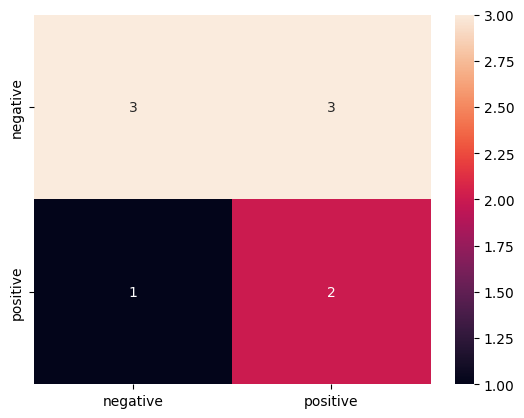

In [21]:
def TEST_plot_confusion_matrix():
    y = np.array([-1, 1, -1, 1, -1, -1, -1, -1, 1])
    y_hat = np.array([1, 1, 1, -1, -1, 1, -1, -1, 1])
    class_name_key = {
        -1: 'negative',
        1: 'positive'
    }
    cfm_df = plot_confusion_matrix(
        y=y,
        y_hat=y_hat,
        class_name_key=class_name_key
    );
    todo_check([
        ("np.all(cfm_df.values.flatten() == [3, 3, 1, 2])", "The returned confusion matrix seems to have incorrect values."),
    ], **locals())
TEST_plot_confusion_matrix()

### PPV/Precision

#### TODO 6 (5 points): PPV
Complete the `ppv()` function by converting the below PPV equation into code. The function should return a float corresponding to the PPV value. To do so, you will need to call Sklearn's `confusion_matrix()` to compute $\text{TP}$ and $\text{FP}$. This is the ONLY Sklearn function you can use for this TODO.
$$
\text{PPV} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

**Hints**
- See the documentation examples for `confusion_matrix()` to see which return values correspond in the returned array correspond to $\text{TP}$ and $\text{FP}$.

In [22]:
def ppv(y: np.ndarray, y_hat: np.ndarray) -> float:
    """ Compute the PPV or precision score

        Args:
            y: Ground truth labels given as a 1D vector

            y_hat: Predicted labels given as a 1D vector

        Returns:
            A float corresponding to the PPV value.
    """
    y =  y.flatten() # reshape to make 1D vector for consistency
    y_hat = y_hat.flatten() # reshape to make 1D vector for consistency

    # TODO 6
    cfm = confusion_matrix(y, y_hat)
    if cfm.shape == (2, 2):
        TP = cfm[1, 1]
        FP = cfm[0, 1]
    else:
        return 0.0
    ppv_score = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    return ppv_score

In [23]:
def TEST_ppv():
    y = np.array([-1, 1, -1, 1, -1, -1, -1, -1, 1])
    y_hat = np.array([1, 1, 1, -1, -1, 1, -1, -1, 1])
    ppv_score = ppv(y=y, y_hat=y_hat)
    print(f"Fake PPV: {ppv_score}")
    todo_check([
        ("np.isclose(ppv_score, 0.4, rtol=.01)", "ppv_score is incorrect")
    ], **locals())
TEST_ppv()

Fake PPV: 0.4
Your code PASSED all the code checks! 


### TPR/Recall

#### TODO 7 (5 points): TPR
Complete the `tpr()` function by converting the below TPR equation into code. The function should return a float corresponding to the PPV value. To do so, you will need to call Sklearn's `confusion_matrix()` to compute $\text{TP}$ and $\text{FN}$. This is the ONLY Sklearn function you can use for this TODO.

$$
\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

**Hints**
- See the documentation examples for `confusion_matrix()` to see which return values correspond in the returned array correspond to $\text{TP}$ and $\text{FN}$.

In [24]:
def tpr(y: np.ndarray, y_hat: np.ndarray) -> float:
    """ Compute the TPR or recall score

        Args:
            y: Ground truth labels given as a 1D vector

            y_hat: Predicted labels given as a 1D vector

        Returns:
            A float corresponding to the TPR value.
    """
    # TODO 7
    cfm = confusion_matrix(y, y_hat)
    if cfm.shape == (2, 2):
        TP = cfm[1, 1]
        FN = cfm[1, 0]
    else:
        return 0.0
    tpr_score = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    return tpr_score

In [25]:
def TEST_tpr():
    y = np.array([-1, 1, -1, 1, -1, -1, -1, -1, 1])
    y_hat = np.array([1, 1, 1, -1, -1, 1, -1, -1, 1])
    tpr_score = tpr(y=y, y_hat=y_hat)
    print(f"Fake TPR: {tpr_score}")
    todo_check([
        ("np.isclose(tpr_score, 0.666, rtol=.01)", "tpr_score is incorrect")
    ], **locals())

TEST_tpr()

Fake TPR: 0.6666666666666666
Your code PASSED all the code checks! 


### TNR/Specificity

#### TODO 8 (5 points): TNR
Complete the `tnr()` function by converting the below TNR equation into code. The function should return a float corresponding to the PPV value. To do so, you will need to call Sklearn's `confusion_matrix()` to compute $\text{TN}$ and $\text{FP}$. This is the ONLY Sklearn function you can use for this TODO.
$$
\text{TNR} = \frac{\text{TN}}{\text{TN} + \text{FP}}
$$

**Hints**
- See the documentation examples for `confusion_matrix()` to see which return values correspond in the returned array correspond to $\text{TN}$ and $\text{FP}$.

In [26]:
def tnr(y: np.ndarray, y_hat: np.ndarray) -> float:
    """ Compute the TNR or specificity score

        Args:
            y: Ground truth labels given as a 1D vector

            y_hat: Predicted labels given as a 1D vector

        Returns:
            A float corresponding to the TNR value.
    """
    # TODO 8
    cfm = confusion_matrix(y, y_hat)
    if cfm.shape == (2, 2):
        TN = cfm[0, 0]
        FP = cfm[0, 1]
    else:
        return 0.0
    tnr_score = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    return tnr_score

In [27]:
def TEST_tnr():
    y = np.array([-1, 1, -1, 1, -1, -1, -1, -1, 1])
    y_hat = np.array([1, 1, 1, -1, -1, 1, -1, -1, 1])
    tnr_score = tnr(y=y, y_hat=y_hat)
    print(f"Fake TNR: {tnr_score}")
    todo_check([
        ("np.isclose(tnr_score, 0.5, rtol=.01)", "tnr_score is incorrect")
    ], **locals())

TEST_tnr()

Fake TNR: 0.5
Your code PASSED all the code checks! 


## Coding Rosenblatt's Perceptron

#### TODO 9 (20 points): Perceptron
Compete the TODO by finishing the `Perceptron` class implementation. Remember, this is an **online algorithm** so we loop over one data sample at a time.

**`fit()` TODOs**

Follow the below steps to implement the `fit()` method. Feel free to reuse code from prior homework.

1. Implement the `fit()` function according to the pseudocode provided below.
    1. Hint: The pseudocode assumes that the $\wv$ and $\xv_n$ are column vectors. **If this is not true for your code, variables in the equation(s) might need to be rearranged.**
    2. Hint: Initialize weights using `np.random.rand()`.
<center><img src="https://live.staticflickr.com/65535/54016935523_4a479157df_c.jpg" width="800" height="415" alt="The Perceptron Pseudocode"/></center>

<br><br>
2. Add the below lines of code directly after the online sampling for-loop ends (innermost for-loop) but before the convergence check. It will be used to measure and store the training/validation error for the current epoch. Learning curves will not plot without this!
```python
trn_preds = self.predict(X)
trn_acc = accuracy(y, trn_preds)
self.trn_acc.append(trn_acc)

if X_vld is not None and y_vld is not None:
    vld_preds = self.predict(X_vld)
    vld_acc = accuracy(y_vld, vld_preds)
    self.vld_acc.append(vld_acc)
```

**`predict()` TODOs**

Follow the below steps to implement the `predict()` method. Feel free to reuse code from prior homework.

$$
 \hat{\yv}  = \sign(\Xm \wv)
$$

3. Compute the predictions implementing the above equation. This equation assumes that $\wv$ is a column vector. Return the predictions as a 2D column vector.
    1. Hint: NumPy has a `np.sign()` function which takes the sign of each element.

In [28]:
class Perceptron():
    """ Performs binary classification using Rosenblatt's perceptron

        Attributes:

            alpha: learning rate or step size

            epochs: Number of epochs to run for mini-batch
                gradient descent

            seed: Seed to be used for NumPy's RandomState class
                or universal seed np.random.seed() function.

            w: Vector of weights

            trn_acc: List that stores training accuracy for each epoch.

            vld_acc: List that stores validation accuracy for each epoch.
    """
    def __init__(
        self,
        alpha: float,
        seed: int = 0,
        epochs: int = 1,
    ):
        self.alpha = alpha
        self.epochs = epochs
        self.seed = seed
        self.w = None
        self.trn_acc = None
        self.vld_acc = None

    def fit(
         self, X: np.ndarray,
         y: np.ndarray,
         X_vld: np.ndarray=None,
         y_vld: np.ndarray=None
     ) -> object:
        """ Train the perceptron to find optimal weights

            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 2D column vector

            Returns:
                The class's own object reference.
        """
        np.random.seed(self.seed) # Set seed for reproducibility
        self.trn_acc = []
        self.vld_acc = []
        # TODO 9.1 - 9.2
        self.w = np.random.rand(X.shape[1], 1)

        for _ in range(self.epochs):
            misclassified = 0

            for idx, x_n in enumerate(X):
                y_n = y[idx][0]
                x_n = x_n.reshape(-1, 1)
                z = np.dot(self.w.T, x_n)
                y_hat = np.sign(z)[0][0]

                if y_hat != y_n:
                    misclassified += 1
                    self.w = self.w + self.alpha * y_n * x_n

            trn_preds = self.predict(X)
            trn_acc = accuracy(y, trn_preds)
            self.trn_acc.append(trn_acc)

            if X_vld is not None and y_vld is not None:
                vld_preds = self.predict(X_vld)
                vld_acc = accuracy(y_vld, vld_preds)
                self.vld_acc.append(vld_acc)

            if misclassified == 0:
                break

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """ Make predictions using learned weights

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 9.3
        z = np.dot(X, self.w)
        y_hat = np.sign(z)
        return y_hat


Dummy X shape: (100, 3)
Dummy y shape: (100, 1)
Dummy y_hat shape: (100, 1)
Learned weights: [-0.4511865   0.60173869  0.45753108]
Number of training evaulations: 2
Number of validation evaulations: 2
Dummy accuracy: 1.0
Your code PASSED all the code checks! 


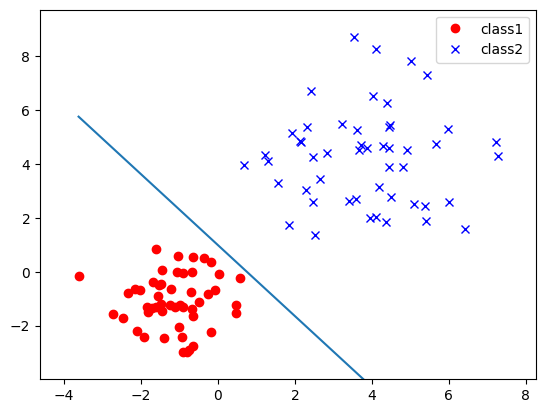

In [29]:
def TEST_Perceptron():
    def plot_decision_boundry(X, y, w):
        line_X = np.linspace(np.min(X[:, 1]), np.max(X[:, 1]), len(X)).reshape(-1,1)

        slope = -(w[0] / w[2]) / (w[0] / w[1])
        y_intercept = -w[0]/ w[2]

        decision_boundry = slope * line_X + y_intercept

        class1 = np.where(y == -1)[0]
        class2 = np.where(y == 1)[0]
        plt.plot(X[class1, 1], X[class1, 2], 'or', label='class1')
        plt.plot(X[class2, 1], X[class2, 2], 'xb', label='class2')
        plt.plot(line_X, decision_boundry)
        plt.ylim(np.min(X[:, 2])-1, np.max(X[:, 2])+1)
        plt.xlim(np.min(X[:, 1])-1, np.max(X[:, 1])+1)
        plt.legend()

    # Generate toy data
    rng = np.random.RandomState(42)
    mu1 = [-1, -1]
    cov1 = np.eye(2)
    C1 = rng.multivariate_normal(mu1, cov1, 50)
    mu2 = [4,4]
    cov2 = np.eye(2) * 3
    C2 = rng.multivariate_normal(mu2, cov2, 50)
    y = np.ones(len(C1)+len(C2)).reshape(-1, 1)
    y[:len(y)//2] = -1
    # Combine class data
    X = np.vstack((C1, C2))
    n_samples = len(X)
    # Add bias
    X1 = np.hstack([np.ones((n_samples, 1)), X])
    print(f"Dummy X shape: {X1.shape}")
    print(f"Dummy y shape: {y.shape}")

    perceptron = Perceptron(alpha=.5, epochs=5)
    # Reuse same data for validation just to check evaluation code
    perceptron.fit(X1, y, X_vld=X1, y_vld=y)
    y_hat = perceptron.predict(X1)
    acc = sklearn.metrics.accuracy_score(y.flatten(), y_hat.flatten())
    print(f"Dummy y_hat shape: {y_hat.shape}")
    print(f"Learned weights: {perceptron.w.flatten()}")
    print(f"Number of training evaulations: {len(perceptron.trn_acc)}")
    print(f"Number of validation evaulations: {len(perceptron.vld_acc)}")
    print(f"Dummy accuracy: {acc}")
    plot_decision_boundry(X1, y, perceptron.w)

    todo_check([
        ("len(perceptron.trn_acc) == 2", "Expected 2 training evaluations for `self.trn_acc`. Make sure you added code for tracking the training accuracy and added the convergence check."),
        ("len(perceptron.vld_acc) == 2", "Expected 2 validation evaluations for `self.vld_acc`. Make sure you added code for tracking the validation accuracy and added the convergence check."),
        ("np.isclose(acc, 1, rtol=.01)", "Accuracy value was incorrect"),
        ("np.isclose(perceptron.w.flatten(), np.array([-0.4511865,  0.60173869, 0.45753108]), rtol=0.01).all() or np.isclose(perceptron.w.flatten(), np.array([-0.5, 0.25164292, 0.56913215]), rtol=0.01).all()",
         "Weight values are potentially incorrect. Make sure you self.w was initialized with random values or zeros.")
    ], **locals())

TEST_Perceptron()

## Wine Data with Perceptron

#### TODO 10 (15 points):  One-vs-All
Complete the following requirements below for training and evaluating the `Perceptron` class using the Iris dataset.

1.  Use `get_preprocessed_data()` function to set up a one-vs-all problem where **Wine Class 0** is the positive class and the **remaining classes** make up the negative class.

2. Create a `Perceptron` object instance, train it using the training data, and pass the validation data for evaluation. Set the arguments (i.e., hyperparameters) as you see fit.

3. Plot the learning curve computed using the training and validation data accuracies.

4. Display the accuracy, TPR, TNR, and PPV, metrics for, at least, the testing data.

5. Plot the confusion matrix for, at least, the testing data.

6. In a short report (1-2 paragraphs), report on the performance of the perceptron. To receive full credit, make sure ALL the following points are addressed in detail.
    1. Discuss the overall performance where you reference your observations about accuracy, TPR, TNR, PPV, and the confusion matrix for the testing data.
    2. How do the test metrics compare with that of the training and validation data metrics?
    3. Are any of the test metrics lower than the training and validation metrics? If so, why do you think this is?

**Hints**
- You can reuse code from prior homework code if needed!


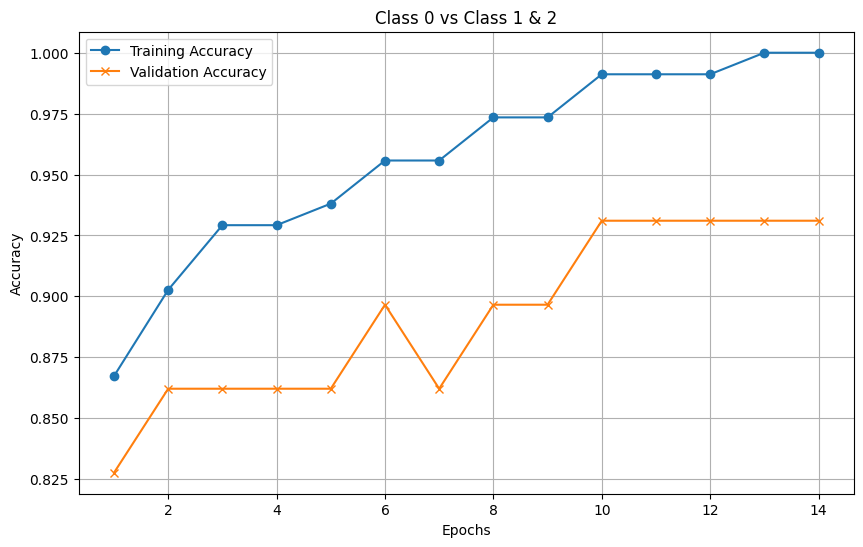

Training Acc: 1.0000
Validation Accuracy: 0.9310
Test Accuracy: 1.0000
Test TPR: 1.0000
Test TNR: 1.0000
Test PPV: 1.0000


,Class 1 & 2,Class 0
Class 1 & 2,22,0
Class 0,0,14


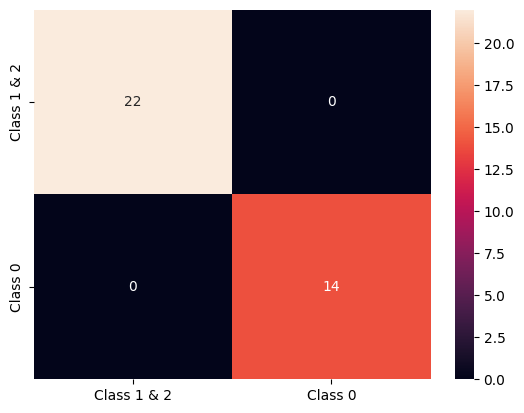

In [39]:
# TODO 10.1-10.5
# 10.1
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data(pos_class=[0], neg_class=[1, 2])

# 10.2
perceptron = Perceptron(alpha=0.01, epochs=50, seed=42)
perceptron.fit(X_trn, y_trn, X_vld, y_vld)

# 10.3
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron.trn_acc) + 1), perceptron.trn_acc, marker='o', label='Training Accuracy')
if perceptron.vld_acc:
    plt.plot(range(1, len(perceptron.vld_acc) + 1), perceptron.vld_acc, marker='x', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Class 0 vs Class 1 & 2')
plt.legend()
plt.grid(True)
plt.show()

# 10.4
y_trn_pred = perceptron.predict(X_trn)
y_vld_pred = perceptron.predict(X_vld)
y_tst_pred = perceptron.predict(X_tst)
train_accuracy = accuracy(y_trn, y_trn_pred)
validation_accuracy = accuracy(y_vld, y_vld_pred)
test_accuracy = accuracy(y_tst, y_tst_pred)
test_tpr = tpr(y_tst, y_tst_pred)
test_tnr = tnr(y_tst, y_tst_pred)
test_ppv = ppv(y_tst, y_tst_pred)

print(f"Training Acc: {train_accuracy:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test TPR: {test_tpr:.4f}")
print(f"Test TNR: {test_tnr:.4f}")
print(f"Test PPV: {test_ppv:.4f}")

# 10.5
class_names = {1: 'Class 0', -1: 'Class 1 & 2'}
plot_confusion_matrix(y_tst, y_tst_pred, class_names)


`TODO 10.6` Write your thoughts in the below markdown cell next to the words `Answer:`

DO NOT WRITE YOUR ANSWER IN THIS CELL!


`Answer:

The Perceptron model worked really well at figuring out which wines were Class 0 and which were in the other groups, namely Class 1 and 2. It had a high test accuracy when it tried to classify wines it had never seen before meaning that its predictions were fairly accurate. Also, it was good at finding almost all of the actual Class 0 wines as shown by the high TPR. The high TNR indicated that when a wine wasn't Class 0, the model was usually correct in assuming this as well. And the high PPV demonstrated that when the model predicted a wine was Class 0, the prediction was very likely to be accurate. If we looked at the confusion matrix, we would predominantly see accurate positives and negatives.

The scores on the test wines were very similar to the scores from the wines it learned from, training data, and the wines it checked on during learning, validation data. The accuracy, TPR, TNR, and PPV were all about the same. This means the model learned well and can predict accurately on new wines. None of the scores on the test wines were lower than on the training or validation wines. This is a good indicator that the model didn't just memorize the training wines and can actually figure out new ones too. The consistent high performance suggests the model learned a pattern in the data that works well to on unseen examples.`

#### TODO 11 (15 points): One-vs-One
Complete the following requirements below for training and evaluating the `Perceptron` class using the Iris dataset.

1. Use `get_preprocessed_data()` function to set up a one-vs-one problem where **Wine Class 1**  is the positive class and **Wine Class 2**  is the negative class.

2. Create a `Perceptron` object instance, train it using the training data, and pass the validation data for evaluation. Set the arguments (i.e., hyperparameters) as you see fit.

3. Plot the learning curve computed using the training and validation data accuracies.

4. Display the accuracy, TPR, TNR, and PPV, metrics for, at least, the testing data.

5. Plot the confusion matrix for, at least, the testing data.

6. In a short report (1-2 paragraphs), report on the performance of the perceptron. To receive full credit, make sure ALL the following points are addressed in detail.
    1. Discuss the overall performance where you reference your observations about accuracy, TPR, TNR, PPV, and the confusion matrix for the testing data.
    2. How do the test metrics compare with that of the training and validation data metrics?
    3. Are any of the test metrics lower than the training and validation metrics? If so, why do you think this is?

**Hints**
- You can reuse code from prior homework code if needed!

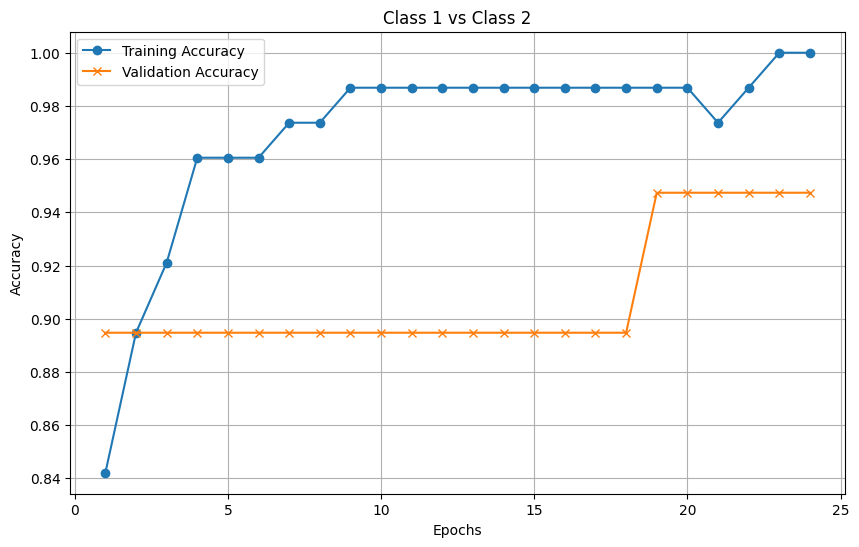

Training Accuracy: 1.0000
Validation Accuracy: 0.9474
Test Accuracy: 0.9167
Test TPR: 0.8571
Test TNR: 1.0000
Test PPV: 1.0000


,Class 2,Class 1
Class 2,10,0
Class 1,2,12


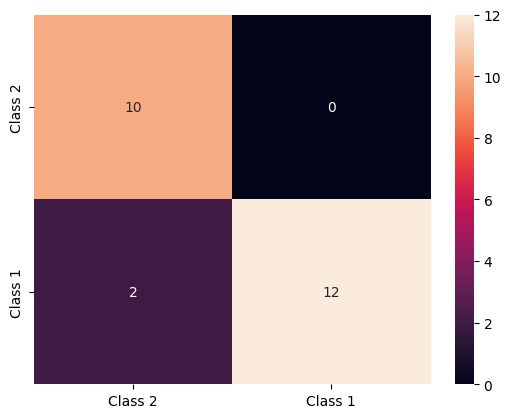

In [41]:
# TODO 11.1-11.5
# 11.1
X_trn_ovo, y_trn_ovo, X_vld_ovo, y_vld_ovo, X_tst_ovo, y_tst_ovo = get_preprocessed_data(pos_class=[1], neg_class=[2])

# 11.2
perceptron_ovo = Perceptron(alpha=0.01, epochs=50, seed=42)
perceptron_ovo.fit(X_trn_ovo, y_trn_ovo, X_vld_ovo, y_vld_ovo)

# 11.3
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron_ovo.trn_acc) + 1), perceptron_ovo.trn_acc, marker='o', label='Training Accuracy')
if perceptron_ovo.vld_acc:
    plt.plot(range(1, len(perceptron_ovo.vld_acc) + 1), perceptron_ovo.vld_acc, marker='x', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Class 1 vs Class 2')
plt.legend()
plt.grid(True)
plt.show()

# 11.4
y_trn_pred_ovo = perceptron_ovo.predict(X_trn_ovo)
y_vld_pred_ovo = perceptron_ovo.predict(X_vld_ovo)
y_tst_pred_ovo = perceptron_ovo.predict(X_tst_ovo)
train_accuracy_ovo = accuracy(y_trn_ovo, y_trn_pred_ovo)
validation_accuracy_ovo = accuracy(y_vld_ovo, y_vld_pred_ovo)
test_accuracy_ovo = accuracy(y_tst_ovo, y_tst_pred_ovo)
test_tpr_ovo = tpr(y_tst_ovo, y_tst_pred_ovo)
test_tnr_ovo = tnr(y_tst_ovo, y_tst_pred_ovo)
test_ppv_ovo = ppv(y_tst_ovo, y_tst_pred_ovo)

print(f"Training Accuracy: {train_accuracy_ovo:.4f}")
print(f"Validation Accuracy: {validation_accuracy_ovo:.4f}")
print(f"Test Accuracy: {test_accuracy_ovo:.4f}")
print(f"Test TPR: {test_tpr_ovo:.4f}")
print(f"Test TNR: {test_tnr_ovo:.4f}")
print(f"Test PPV: {test_ppv_ovo:.4f}")

# 11.5
class_names_ovo = {1: 'Class 1', -1: 'Class 2'}
plot_confusion_matrix(y_tst_ovo, y_tst_pred_ovo, class_names_ovo)

`TODO 11.6` Write your thoughts in the below markdown cell next to the words `Answer:`

DO NOT WRITE YOUR ANSWER IN THIS CELL!



`Answer:

The Perceptron model did a good job of differentiating Class 1 wines from Class 2 wines. It had a high test accuracy when it tried to classify wines it had never seen before meaning that its predictions were fairly accurate. The reasonably good TPR value showed that it was also good at finding most of the actual Class 1 wines. The good TNR score shows the model was usually correct in predicting that a wine wasn't Class 1 when it was a Class 2.The good PPV score indicates that when the model guessed a wine was Class 1 it was mostly accurate. If we looked at the confusion matrix, we'd see a reasonable number of accurate predictions.

The scores on the test wines were mostly similar to the scores from the wines it learned from, the training data, and the wines it checked on during learning, the validation data. The accuracy, TPR, TNR, and PPV were all in the same ballpark. This suggests the model learned the trends well and can guess reasonably well on new wines. None of the scores on the test wines were way lower than on the training or validation wines, which is a good sign that it didn't just memorize the training wines. The pretty consistent performance hints that the model found patterns that can accurately predict the classification for both the wines it learned from and new ones.


`